In [1]:
import ast
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
import pandas as pd
import seaborn as sns

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df = df[df['job_country'] == 'United States']



In [3]:
df_job_titles_count = df['job_title_short'].value_counts().reset_index(name='jobs_total')
df_job_titles_count 

,job_title_short,jobs_total
0,Data Analyst,67816
1,Data Scientist,58830
2,Data Engineer,35080
3,Senior Data Scientist,12946
4,Senior Data Analyst,11791
5,Senior Data Engineer,9289
6,Business Analyst,7382
7,Software Engineer,1814
8,Machine Learning Engineer,921
9,Cloud Engineer,423


In [4]:
df_explode = df.explode('job_skills')
df_grouped = df_explode.groupby(['job_title_short', 'job_skills']).size().reset_index(name='count')
df_grouped.sort_values('count', ascending=False, inplace=True)

df_grouped 

,job_title_short,job_skills,count
886,Data Scientist,python,42379
472,Data Analyst,sql,34452
921,Data Scientist,sql,30034
351,Data Analyst,excel,27519
890,Data Scientist,r,26022
...,...,...,...
1350,Senior Data Engineer,elixir,1
1819,Software Engineer,sass,1
487,Data Analyst,theano,1
1847,Software Engineer,theano,1


In [5]:
df_skills_percent = pd.merge(df_grouped, df_job_titles_count, on='job_title_short', how='left')
df_skills_percent['skill_percent'] = df_skills_percent['count'] / df_skills_percent['jobs_total'] * 100
df_skills_percent

,job_title_short,job_skills,count,jobs_total,skill_percent
0,Data Scientist,python,42379,58830,72.036376
1,Data Analyst,sql,34452,67816,50.802171
2,Data Scientist,sql,30034,58830,51.052184
3,Data Analyst,excel,27519,67816,40.578919
4,Data Scientist,r,26022,58830,44.232534
...,...,...,...,...,...
1865,Senior Data Engineer,elixir,1,9289,0.010765
1866,Software Engineer,sass,1,1814,0.055127
1867,Data Analyst,theano,1,67816,0.001475
1868,Software Engineer,theano,1,1814,0.055127


In [6]:
job_titles = df_grouped['job_title_short'].unique().tolist()
job_titles = sorted(job_titles[:3])
job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

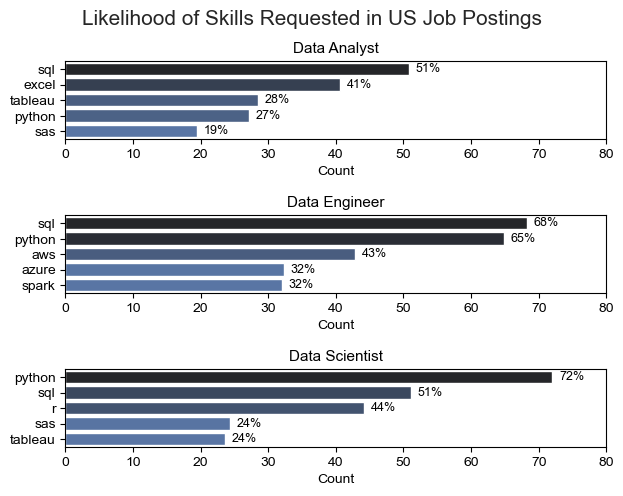

In [7]:
fig, ax = plt.subplots(len(job_titles), 1)


sns.set_theme(style='ticks')
for i, job_title in enumerate(job_titles):
    job_data = df_skills_percent[df_skills_percent['job_title_short'] == job_title].head(5)
    #ax[i].barh(job_data['job_skills'], job_data['count'])
    #plt.barh(data=job_data, y='job_skills', width='count', ax= x[i])
    sns.barplot(data=job_data, y='job_skills', x='skill_percent', ax=ax[i], hue='skill_percent', palette='dark:b_r', legend=False)
    ax[i].set_title(f'{job_title}', fontsize=11)
    ax[i].set_xlabel('Count')
    ax[i].set_ylabel('')
    ax[i].set_xlim(0, 80)
    
    for n, v in enumerate(job_data['skill_percent']):
        ax[i].text(v + 1, n, f'{v:.0f}%', color='black', va='center', fontsize=9)
   



plt.tight_layout()
plt.suptitle('Likelihood of Skills Requested in US Job Postings', fontsize=15, y=1.03)
plt.show()